# **A. ORCHESTRATOR AGENT**

```
TEFPA = Task + Experience + Function + Performance + Algorithm
```
**Task:**
- **Input:** Chuỗi văn bản (User prompt).  
- **Output:** Nhãn `1` (Healthcare consultant search) hoặc `2` (Healthcare center search) và nhãn `0` (others).
- **Ràng buộc:** Xử lý tuần tự từ ngữ (time-series data), trả về xác suất từ 0 đến 1 để rẽ nhánh logic code.

**Experience (Dữ liệu)**
- **Dataset:** Tự tạo \~150 câu mẫu cho mỗi lớp (Data thô).  
- **Tiền xử lý:**
    - **Tokenization:** Chuyển chữ thành mảng số (Index).  
    - **Padding:** Cắt/thêm số `0` để các câu có cùng độ dài (để nạp vào RNN).

**Function (Mô hình)**

- **Kiến trúc:** Dùng Keras `Sequential` xếp tầng từ đầu:  
    - `Embedding`: Biến các chỉ số từ thành vector không gian.  
    - `SimpleRNN`: Học ngữ cảnh tuần tự của câu prompt.  
    - `Dense(1, activation='sigmoid')`: Nén đầu ra về khoảng \[0, 1\].

**Performance (Đánh giá)**
- **Loss function:** `binary_crossentropy` (Hàm lỗi chuẩn cho phân loại nhị phân).
- **Metric:** `accuracy` (Độ chính xác để theo dõi khi train).

**Algorithm (Huấn luyện)**
- **Optimizer:** `AdamW` hoặc `RMSprop` (Giải thuật gradient descent tối ưu hóa trọng số mạng).
- **Cách chạy:** `model.fit()` chạy qua vài chục vòng (epochs) trên mini-dataset tự chế cho đến khi loss hội tụ.

## 1. Dataset
- Add shortcut [Drive Side Project](https://drive.google.com/drive/folders/1LzKlxYGWWYHPiEleqHFIsiqugj1yqK7d) vào MyDrive.
- Mount Drive vào Colab.

Dùng `pandas` để đọc bảng `Training/smallDataset.tsv`

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/7. Side Project Dr. Minh/Training")

import pandas as pd
df = pd.read_csv("smallDataset - v6.tsv", sep='\t')
df = df.dropna(subset=["text", "label"])
df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
df.tail(5)

Mounted at /content/drive


,text,label
3131,"Máy ổ cứng cứ bị camera bị mờ, nguyên nhân thư...",other
3132,"Tôi muốn mua ổ cứng dùng học tập, nên chọn loạ...",other
3133,"Dạo này đô la biến động mạnh, có nên theo dõi ...",other
3134,"Cho tôi hỏi đô la hôm nay tăng hay giảm, nên x...",other
3135,Người mới tìm hiểu đô la thì cần học những khá...,other


## EDA for special patterns

Check for links, hashtags, HTML tags, emojis and numbers in dataset.

In [2]:
import re
emoji_pattern = re.compile("["
                               "\U0001F600-\U0001F64F"  # emoticons
                               "\U0001F300-\U0001F5FF"  # symbols & pictographs
                               "\U0001F680-\U0001F6FF"  # transport & map symbols
                               "\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               "\U00002702-\U000027B0"  # Dingbats
                               "\U000024C2-\U0001F251"  # Enclosed characters
                               "]+", flags=re.UNICODE)

def check_link(text):
  return bool(re.search(r'http\S+|www\S+', str(text)))

def check_hashtag(text):
  return bool(re.search(r'#\w+', str(text)))

def contains_html(text):
  return bool(re.search(r'<[^>]+>', str(text)))

def contains_number(text):
  return bool(re.search(r'\d+', str(text)))

def contains_emoji(text):
  return bool(emoji_pattern.search(str(text)))

eda_df = df.copy()
eda_df['has_link'] = eda_df['text'].apply(check_link)
eda_df['has_hashtag'] = eda_df['text'].apply(check_hashtag)
eda_df['has_html'] = eda_df['text'].apply(contains_html)
eda_df['has_number'] = eda_df['text'].apply(contains_number)
eda_df['has_emoji'] = eda_df['text'].apply(contains_emoji)

print("--- Summary of Special Patterns ---")
print(f"Texts with links: {eda_df['has_link'].sum()} out of {len(eda_df)}")
print(f"Texts with hashtags: {eda_df['has_hashtag'].sum()} out of {len(eda_df)}")
print(f"Texts with HTML tags: {eda_df['has_html'].sum()} out of {len(eda_df)}")
print(f"Texts with numbers: {eda_df['has_number'].sum()} out of {len(eda_df)}")
print(f"Texts with emojis: {eda_df['has_emoji'].sum()} out of {len(eda_df)}")

--- Summary of Special Patterns ---
Texts with links: 17 out of 3136
Texts with hashtags: 19 out of 3136
Texts with HTML tags: 0 out of 3136
Texts with numbers: 489 out of 3136
Texts with emojis: 322 out of 3136


Thay vì dùng `matplotlib` để vẽ chart tĩnh, hãy dùng `plotly express` để vẽ 2 interactive charts gồm:
- `Box plot` cho độ dài `text` trung bình tính theo words, đây cũng sẽ là thống kê số tokens trung bình cần xử lý.
- `Pie chart` cho tỉ lệ các class có trong dataset.

In [3]:
# YOUR CODE GOES HERE
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

temp = df.copy()

temp['text_length'] = temp['text'].apply(lambda x: len(str(x).split()))

fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'xy'}, {'type': 'domain'}]], subplot_titles=['Query length (in words)', 'Labels Distribution'])

# Box plot is the first subplot
fig_box = px.box(temp, y='text_length', title='Query length (in words)')
for trace in fig_box.data:
  fig.add_trace(go.Box(y=trace.y, name=trace.name), 1, 1)

# Pie chart is second subplot
fig_pie = px.pie(temp, names='label', title='Labels Distribution')
for trace in fig_pie.data:
  fig.add_trace(go.Pie(labels=trace.labels, values=trace.values, name=trace.name), 1, 2)

fig.update_layout(title_text="Query length and Labels Distribution")
fig.show()

In [4]:
# Bins of length
bins = [0, 5, 10, 20, 50, float('inf')]
labels = ['<5', '<10', '<20', '<50', '>=50']

temp['length_bins'] = pd.cut(temp['text_length'], bins=bins, labels=labels, right=False)

bin_counts = temp['length_bins'].value_counts().sort_index().reset_index()
bin_counts.columns = ['length_bin', 'count']

# Create the bar chart
fig_bar = px.bar(bin_counts, x='length_bin', y='count',
                 title='Bins of Query length',
                 labels={'length_bin': 'Query Length Bin', 'count': 'Number of Queries'})

fig_bar.show()

Ngoài 24 chữ cái alphabet, ta in thử vài dòng sẽ thấy có những câu có những ký hiệu đặc biệt như `!`, `?`, `...`, viết hoa - thường lung tung hay emoji. Chúng ta sẽ xử lý nó sau nhé.

Do không có quá nhiều dữ liệu nên chỉ split dataset thành 2 tập: `Train` và `Test`.

In [5]:
# YOUR CODE GOES HERE
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

train_temp = train.copy()
test_temp = test.copy()

train_temp['text_length'] = train_temp['text'].apply(lambda x: len(str(x).split()))
test_temp['text_length'] = test_temp['text'].apply(lambda x: len(str(x).split()))

fig_inspect = make_subplots(rows=2, cols=2, specs=[[{'type': 'xy'}, {'type': 'domain'}],
                                                   [{'type': 'xy'}, {'type': 'domain'}]],
                            subplot_titles=['Train Query length', 'Train Labels Distribution', 'Test Query Length', 'Test Labels Distribution'])

# Box plots are in the first col
box_train = px.box(train_temp, y='text_length')
box_test = px.box(test_temp, y='text_length')

for trace in box_train.data:
  fig_inspect.add_trace(go.Box(y=trace.y, name=trace.name), 1, 1)
for trace in box_test.data:
  fig_inspect.add_trace(go.Box(y=trace.y, name=trace.name), 2, 1)

# Pie charts are in the second col
pie_train = px.pie(train_temp, names='label')
pie_test = px.pie(test_temp, names='label')

for trace in pie_train.data:
  fig_inspect.add_trace(go.Pie(labels=trace.labels, values=trace.values, name=trace.name), 1, 2)
for trace in pie_test.data:
  fig_inspect.add_trace(go.Pie(labels=trace.labels, values=trace.values, name=trace.name), 2, 2)

fig_inspect.update_layout(title_text="Inspect the split")
fig_inspect.show()

Lưu ý:
- Các khác biệt trên sẽ làm cho kết quả của mô hình không được tốt → đây chính là lý do mà bạn cần có 1 tập Train đủ lớn để mô hình có thể chạy tốt trong thực tế. Tuy nhiên, không phải lúc nào ta cũng có sẵn 1 lượng lớn dữ liệu về 1 domain nào đó. Sau này ta sẽ học về khái niệm Language Model, Language Model sẽ giúp ta giải quyết vấn đề này.

## 2. Preprocessing
Lưu ý: khi thực hiện Tokenizer và Embedding, chỉ được thao tác trên tập Train. Điều này dẫn đến khi kiểm thử mô hình trên tập Validation và Test sẽ có thể xảy ra các trường hợp sau:

- Trong 2 tập Val-Test xuất hiện các từ chưa bao giờ xuất hiện trong tập Train
- Trong 2 tập Val-Test xuất hiện các document quá dài hoặc quá ngắn so với tập Train

### a. Filter special character (Train, Test)
- Đây là kỹ thuật dùng [`regular expression`](https://www.reddit.com/r/vim/comments/32r85c/this_is_my_favorite_vim_cheat_sheet_does_anyone/#lightbox) để xóa các ký tự đặc biệt.
- Mục đích: Giảm số token cần học, chỉ để model học word, không học emoji gây nhiễu.

What Thái add: see number of rows with 😀emojis in the dataset; replace links with `link`

In [6]:
import re
emoji_pattern = re.compile("["
                               "\U0001F600-\U0001F64F"  # emoticons
                               "\U0001F300-\U0001F5FF"  # symbols & pictographs
                               "\U0001F680-\U0001F6FF"  # transport & map symbols
                               "\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               "\U00002702-\U000027B0"  # Dingbats
                               "\U000024C2-\U0001F251"  # Enclosed characters
                               "]+", flags=re.UNICODE)
def simple_preprocessing(text):
    # Remove emojis
    text = emoji_pattern.sub(r'', text)
    # Remove special characters excluding underscore (_)
    text = re.sub(r'[^\w\s_]', ' ', text)

    # Remove links
    text = re.sub(r'http\S+|www\S+', 'link', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+(\.\d+)?(/[\d.]+)?', '', text)

    # xóa các kí tự đặc biệt có thể dẫn đến việc tạo ra khoảng trắng dư thừa
    # ví dụ "huhu :((  buồn quá" sẽ thành "huhu    buồn quá"
    # ta sẽ split text theo khoảng trắng rồi join lại để sửa trường hợp này
    text = " ".join(text.split())
    text = text.strip().lower()
    return text

Không viết lại code ở trên, hãy thử áp dụng codebase có sẵn của Hỷ để viết hàm filter DataFrame hiện tại.

In [7]:
# YOUR CODE GOES HERE
def filter():
  train['text'] = train['text'].apply(lambda x: simple_preprocessing(x))
  test['text'] = test['text'].apply(lambda x: simple_preprocessing(x))
  return train, test

train, test = filter()
smoke = train.copy()
smoke['has_numbers'] = smoke['text'].apply(contains_number)
print(f"Texts with numbers: {smoke['has_numbers'].sum()} out of {len(smoke)}")

Texts with numbers: 0 out of 2508


### Stopword Removal

Stopword removal is the process of eliminating common words that carry little semantic meaning (e.g., 'là', 'thì', 'và' in Vietnamese). Removing these words can:

- **Reduce vocabulary size**: Leading to smaller embedding matrices and faster training/inference.
- **Improve signal-to-noise ratio**: Helping the model focus on more important words for classification.
- **Reduce dimensionality**: Making the feature space sparser and potentially improving model performance for some tasks.

For Vietnamese, a custom list of stopwords is often more effective than generic lists. I'll use a common set of Vietnamese stopwords for this step.

In [8]:
# Stopword removal
vietnamese_stopwords = [
    'là', 'thì', 'và', 'của', 'có', 'trong', 'trên', 'với', 'từ', 'đến', 'như', 'mà', 'khi', 'quá', 'omg', 'trời ơi',
    'đã', 'sẽ', 'không', 'vẫn', 'cũng', 'đang', 'chưa', 'nếu', 'thì', 'hay', 'rất', 'quá', 'nhưng', 'vậy', 'ơi',
    'những', 'một', 'hai', 'ba', 'bốn', 'năm', 'sáu', 'bảy', 'tám', 'chín', 'mười', 'mươi', 'lăm', 'ngàn', 'nghìn', 'triệu',
    'anh', 'chị', 'em', 'tôi', 'chúng tôi', 'bạn', 'các bạn', 'họ', 'ông', 'bà', 'mình', 'cậu', 'tớ', 'chú', 'dì', 'mợ', 'dượng', 'bác',
]

def remove_stopwords(words_list):
    if not isinstance(words_list, list):
        return []
    filtered_words = [word for word in words_list if word not in vietnamese_stopwords]
    return filtered_words


### b. Lemmatization/Stemming (Tham khảo)
- Đây là kỹ thuật chuyển mọi word form thành bare form của nó.
- Ví dụ: "running" thành "run".
- Mục đích: thay vì 2 token khác nhau thì ta chỉ cần 1 token để handle được cả 2 chữ này.

Do Tiếng Việt không có word form nên không áp dụng được nhé. Code mẫu từ `nltk` để làm bước này như sau.

In [9]:
import nltk
from nltk.stem import WordNetLemmatizer

# Download the required WordNet data (only need to run this once)
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [10]:
words = ["running", "flies", "better"]

# Default for noun lemmatizer
print('Noun')
for word in words:
    print(f"{word} -> {lemmatizer.lemmatize(word)}")

# Verb lemmatizer
print('\nVerb')
for word in words:
    print(f"{word} -> {lemmatizer.lemmatize(word, pos='v')}")

# Adjective lemmatizer
print('\nAdjective')
for word in words:
    print(f"{word} -> {lemmatizer.lemmatize(word, pos='a')}")

Noun
running -> running
flies -> fly
better -> better

Verb
running -> run
flies -> fly
better -> better

Adjective
running -> running
flies -> flies
better -> good


### c. Tokenization (Tham khảo)

* Đây là kỹ thuật tách văn bản thô (câu, đoạn văn) thành các phần tử nhỏ hơn gọi là "token" (từ đơn, từ ghép hoặc ký tự).  
* Ví dụ: "Học lập trình" thành `["Học", "lập", "trình"]`.  
* Mục đích: Chuẩn hóa văn bản thành dạng danh sách để máy tính có thể đếm tần suất và chuyển thành chuỗi số trước khi đưa vào mô hình.

Song, đây là phương pháp khá cũ, chỉ dùng để tham khảo thêm. Code mẫu sử dụng `Keras Tokenizer` để thực hiện bước này như sau.

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentences = [
    "Tôi thích học lập trình",
    "Học lập trình rất vui",
    "Tôi đang học Keras và Tensorflow"
]

# 1. Khởi tạo Tokenizer
# oov_token: Từ thay thế cho các từ mới không nằm trong từ điển khi test/predict
tokenizer = Tokenizer(num_words=300, oov_token="<OOV>")

# 2. "Học" từ điển từ dữ liệu văn bản
tokenizer.fit_on_texts(sentences)

# Xem từ điển index được tạo ra (Word Index)
word_index = tokenizer.word_index
print("--- Từ điển Word Index ---")
print(word_index)

# 3. Chuyển câu văn bản thành chuỗi số (Sequences)
sequences = tokenizer.texts_to_sequences(sentences)
print("\n--- Văn bản sau khi chuyển thành chuỗi số ---")
for text, seq in zip(sentences, sequences):
    print(f"'{text}' -> {seq}")

--- Từ điển Word Index ---
{'<OOV>': 1, 'học': 2, 'tôi': 3, 'lập': 4, 'trình': 5, 'thích': 6, 'rất': 7, 'vui': 8, 'đang': 9, 'keras': 10, 'và': 11, 'tensorflow': 12}

--- Văn bản sau khi chuyển thành chuỗi số ---
'Tôi thích học lập trình' -> [3, 6, 2, 4, 5]
'Học lập trình rất vui' -> [2, 4, 5, 7, 8]
'Tôi đang học Keras và Tensorflow' -> [3, 9, 2, 10, 11, 12]


### d. Word Tokenizer/Word Segmentation (Train)
- Đây là kỹ thuật chia nhỏ một câu hoặc đoạn văn bản thành các từ cấu thành nên nó.  
- Ví dụ: "Học lập trình" thành `["Học", "lập trình"]` (tách theo từ ghép)
- Mục đích: Định vị rõ ràng ranh giới của từng từ, giúp mô hình hiểu được cấu trúc cú pháp và ý nghĩa của câu.

Đối với Tiếng Việt, do từ ghép có chứa khoảng trắng, ta cần dùng thư viện chuyên dụng như `underthesea` thay vì chỉ `split()` bằng khoảng trắng như Tiếng Anh. Code mẫu để thực hiện bước này như sau.

In [12]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.7 MB/s eta 0:00:00


In [13]:
from underthesea import word_tokenize

# Text mẫu sau khi bỏ dấu
raw_texts = [
    "Con bị sốt rất cao phải làm sao",
    "Bệnh viện Từ Dũ đi đường nào"
]

# Bước tách từ phức Tiếng Việt
processed_texts = []
for text in raw_texts:
    # format="chuan_hoa" sẽ tự động chuyển các từ phức thành dạng segment
    segmented_text = word_tokenize(text, format="chuan_hoa")
    processed_texts.append(segmented_text)

print(processed_texts)

[['Con', 'bị', 'sốt', 'rất', 'cao', 'phải', 'làm sao'], ['Bệnh viện', 'Từ Dũ', 'đi', 'đường', 'nào']]


Hãy dùng `word tokenizer` cho DataFrame của mình nhé. Trên thực tế, ta sẽ có khái niệm `VOCAB_SIZE` là giới hạn số lượng từ trong từ điển để tránh OOM hay lãng phí tài nguyên phần cứng.

In [14]:
# YOUR CODE GOES HERE
def tokenize(text):
  if not isinstance(text, str):
    return ""
  # Step 1: Word segment using underthesea
  segmented_words = word_tokenize(text, format="chuan_hoa")
  # Step 2: Remove stopwords from the segmented words
  filtered_words = remove_stopwords(segmented_words)
  return " ".join(filtered_words)

train['text_tok'] = train['text'].apply(tokenize)
test['text_tok'] = test['text'].apply(tokenize)
display(train[['text', 'text_tok']].head())

tokenizer.fit_on_texts(train['text_tok'])
word_index = tokenizer.word_index
print(f"Vocab size (including <OOV>): {len(word_index)}")
print("Most popular 20 words and their token IDs from the vocab:")
for i, (word, idx) in enumerate(word_index.items()):
  if i >= 20:
    break
  print(f"{word}: {idx}")

,text,text_tok
532,bé nhà tôi tuổi cứ về đêm là ho sặc sụa có đờm...,bé nhà tuổi cứ về đêm ho sặc sụa đờm nghe phổi...
2044,phòng khám đa khoa quốc tế có tổng đài đặt lịc...,phòng khám đa khoa quốc tế tổng đài đặt lịch k...
2173,phòng khám sản phụ khoa có khám cho người lớn ...,phòng khám sản phụ khoa khám cho người lớn tuổ...
1,bệnh viện da liễu trung ương nằm ở phố nào vậy...,bệnh viện da liễu trung ương nằm ở phố nào
192,triệu chứng của bệnh sốt xuất huyết là gì,triệu chứng bệnh sốt xuất huyết gì


Vocab size (including <OOV>): 2345
Most popular 20 words and their token IDs from the vocab:
<OOV>: 1
nào: 2
cho: 3
nên: 4
khám: 5
bị: 6
bệnh: 7
viện: 8
muốn: 9
cần: 10
đi: 11
làm: 12
hỏi: 13
ở: 14
người: 15
sĩ: 16
bác: 17
để: 18
phòng: 19
thuốc: 20


Now that the tokenizer is fitted, you can convert your tokenized text (from the `text_tok` column) into sequences of token IDs. Let's see an example:

In [15]:
train_sequences = tokenizer.texts_to_sequences(train['text_tok'])

print("Original tokenized text for the first training sample:")
print(train['text_tok'].iloc[0])
print("\nCorresponding token IDs for the first training sample:")
print(train_sequences[0])

Original tokenized text for the first training sample:
bé nhà tuổi cứ về đêm ho sặc sụa đờm nghe phổi tiếng rít cháu bị hen phế quản ạ

Corresponding token IDs for the first training sample:
[1, 24, 84, 130, 237, 87, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 1, 1, 1, 50]


### e. Padding (Train)
- Đây là kỹ thuật thêm các ký tự đặc biệt (thường là số `0`) vào các chuỗi số ngắn hơn để tất cả các câu trong tập dữ liệu có cùng một độ dài cố định.  
- Ví dụ: Chuỗi `[3, 6, 2]` và `[2, 4, 5, 7]` sau khi padding về độ dài 5 sẽ thành `[3, 6, 2, 0, 0]` và `[2, 4, 5, 7, 0]`.  
- Mục đích: Đảm bảo dữ liệu đầu vào có kích thước đồng nhất (dạng ma trận/tensor), vì các mô hình Deep Learning yêu cầu kích thước input cố định để xử lý theo batch.

Bạn có thể chọn thêm số 0 vào phía sau (`padding='post'`) hoặc phía trước (`padding='pre'`). Code mẫu sử dụng `pad_sequences` từ Keras để làm bước này như sau:

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 3

# Giả sử đây là kết quả sau khi chuyển văn bản thành chuỗi số (độ dài không bằng nhau)
sequences = [
    [3, 6, 2],       # Độ dài 3
    [2, 4, 5, 7]     # Độ dài 4
]

# Thực hiện padding để đưa về cùng độ dài tối đa là max_length
# padding='post': thêm số 0 vào phía sau
padded_sequences = pad_sequences(sequences, padding='post', maxlen=max_length)

print("Chuỗi số sau khi Padding:")
print(padded_sequences)

Chuỗi số sau khi Padding:
[[3 6 2]
 [4 5 7]]


Hãy áp dụng `padding sequence` cho dataset của mình với `max_length` là độ dài trung bình của các vector token nhé.

In [17]:
# YOUR CODE GOES HERE
max_length2 = train['text_tok'].apply(lambda x: len(x.split())).mean()
max_length2 = int(max_length2)
print(train_sequences[0])
train_df2 = pad_sequences(train_sequences, padding='post', maxlen=max_length)
print(train_df2[0])
print("Max length of an input:", max_length2)

[1, 24, 84, 130, 237, 87, 1, 1, 1, 1, 1, 1, 1, 1, 1, 6, 1, 1, 1, 50]
[ 1  1 50]
Max length of an input: 18


### Experimenting with length

In [18]:
max_length = train['text_tok'].apply(lambda x: len(x.split()))
max_length = int(max_length.quantile(0.95))
print(max_length)
train_df = pad_sequences(train_sequences, padding='post', maxlen=max_length)
print("Max length of an input:", max_length)

28
Max length of an input: 28


### f. One-hot-encoding (Train, Test)
- Quen quá rồi nên không nói lại đâu.

Hãy áp dụng `ohe` cho trường `label` của dataset mình nhé.

In [19]:
# YOUR CODE GOES HERE
from sklearn.preprocessing import OneHotEncoder as ohe

enc = ohe(handle_unknown="error", sparse_output=False)
train_enc = enc.fit_transform(train['label'].values.reshape(-1, 1))
test_enc = enc.transform(test['label'].values.reshape(-1, 1))

print("Train shape", train_enc.shape)
print("Test shape", test_enc.shape)

Train shape (2508, 3)
Test shape (628, 3)


## 3. Model architecture

- **SimpleRNN (Mạng hồi quy đơn giản):**  
  - *Khái niệm:* Là layer RNN cơ bản nhất. Nó xử lý dữ liệu theo từng bước thời gian (từ này qua từ khác) và có một bộ nhớ ngắn hạn để chuyển thông tin từ bước trước sang bước sau.  
  - *Đặc điểm:* Dễ bị hiện tượng "mất mát đạo hàm" (Vanishing Gradient) nên không nhớ được các ngữ cảnh quá xa trong câu dài.  
- **LSTM (Long Short-Term Memory):**  
  - *Khái niệm:* Phiên bản nâng cấp của SimpleRNN, được thiết kế thêm các "cổng" (Gates) để kiểm soát luồng thông tin (cho phép nhớ dữ liệu quan trọng và quên dữ liệu nhiễu).  
  - *Đặc điểm:* Giải quyết xuất sắc bài toán ghi nhớ ngữ cảnh dài (Long-term dependencies).  
- **Bidirectional (Mạng hai chiều):**  
  - *Khái niệm:* Không phải là một layer đứng độc lập, mà là một **wrapper** (lớp bọc) quanh các layer RNN (như `Bidirectional(LSTM(...))`).  
  - *Đặc điểm:* Cho phép mô hình đọc chuỗi dữ liệu theo cả 2 chiều: từ trái sang phải (xuôi) và từ phải sang trái (ngược). Giúp mô hình hiểu từ ngữ dựa vào cả ngữ cảnh đứng trước lẫn đứng sau nó.
- **GRU**

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, TimeDistributed, GRU, Bidirectional, Dropout, PReLU

VOCAB_SIZE = 100      # Số từ trong từ điển
EMBEDDING_DIM = 16    # Số chiều vector từ
MAX_LENGTH = 10       # Độ dài sequence (số lượng token trong 1 câu)
NUM_CLASSES = 3       # Số lớp phân loại

# Takes token IDs sentence, process through embedding + RNN layers -> class probability
model = Sequential([
    # 1. Layer Input: Định hình kích thước dữ liệu đầu vào.
    # Dữ liệu truyền vào là một vector chứa MAX_LENGTH số nguyên (ID của từ).
    Input(shape=(MAX_LENGTH,)),

    # 2. Layer Embedding: Nhận ma trận số nguyên và chuyển thành ma trận vector đặc trưng.
    # return_sequences output hidden state H tại từng timestep
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, EMBEDDING_DIM)
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),

    # 3. Layer SimpleRNN: Xử lý chuỗi, giữ lại cấu trúc thời gian để chuyển tiếp cho lớp sau.
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, 32)
    SimpleRNN(units=32, activation='tanh', return_sequences=True),

    # 0. Layer TimeDistributed: Áp dụng Dense layer lên từng vị trí token độc lập.
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, 16)
    TimeDistributed(Dense(16, activation='relu')),

    # 4. Layer LSTM: Đọc chuỗi đã xử lý và nén thông tin về trạng thái cuối cùng (Flatten chuỗi).
    # Kích thước đầu ra: (batch_size, 64)
    LSTM(units=64, activation='tanh', return_sequences=False, recurrent_activation='sigmoid'),

    # 5. Layer ẩn Dense kết nối dày đặc
    Dense(32, activation='relu'),

    # 6. Layer Output: Phân loại đa lớp
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adamW',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 16)         │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 10, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,611 (103.95 KB)

 Trainable params: 26,611 (103.95 KB)

 Non-trainable params: 0 (0.00 B)

Hãy tạo 1 kiến trúc bất kỳ để giải quyết bài toán này. Vì đây là bài toán khá dễ nên hi vọng mọi thứ vẫn sẽ ổn nha.

In [21]:
# YOUR CODE GOES HERE
MAX_LENGTH = max_length
EMBEDDING_DIM = 64
VOCAB_SIZE = len(word_index) + 1
NUM_CLASSES = df['label'].nunique()
print(VOCAB_SIZE)

model_2 = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
    Bidirectional(LSTM(units=32, activation='tanh', recurrent_activation='sigmoid')),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model_2.compile(loss='categorical_crossentropy', optimizer='adamW', metrics=['accuracy'])
model_2.summary()

2346


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 28, 64)         │       150,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,155 (692.01 KB)

 Trainable params: 177,155 (692.01 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Experiment 3
MAX_LENGTH = max_length
EMBEDDING_DIM = 32
VOCAB_SIZE = len(word_index) + 1
NUM_CLASSES = df['label'].nunique()
print(VOCAB_SIZE)

model3 = Sequential([
    # 1. Layer Input: Định hình kích thước dữ liệu đầu vào.
    # Dữ liệu truyền vào là một vector chứa MAX_LENGTH số nguyên (ID của từ).
    Input(shape=(MAX_LENGTH,)),

    # 2. Layer Embedding: Nhận ma trận số nguyên và chuyển thành ma trận vector đặc trưng.
    # return_sequences output hidden state H tại từng timestep
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, EMBEDDING_DIM)
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),

    # 3. Layer SimpleRNN: Xử lý chuỗi, giữ lại cấu trúc thời gian để chuyển tiếp cho lớp sau.
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, 32)
    SimpleRNN(units=32, activation='tanh', return_sequences=True),

    # 0. Layer TimeDistributed: Áp dụng Dense layer lên từng vị trí token độc lập.
    # Kích thước đầu ra: (batch_size, MAX_LENGTH, 16)
    TimeDistributed(Dense(16, activation='relu')),

    # 4. Layer LSTM: Đọc chuỗi đã xử lý và nén thông tin về trạng thái cuối cùng (Flatten chuỗi).
    # Kích thước đầu ra: (batch_size, 64)
    LSTM(units=64, activation='tanh', return_sequences=False, recurrent_activation='sigmoid'),

    # 5. Layer ẩn Dense kết nối dày đặc
    Dense(32, activation='relu'),

    # 6. Layer Output: Phân loại đa lớp
    Dense(NUM_CLASSES, activation='softmax')
])

model3.compile(loss='categorical_crossentropy', optimizer='adamW', metrics=['accuracy'])
model3.summary()

2346


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 28, 32)         │        75,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 28, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 28, 16)         │           528 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,595 (392.95 KB)

 Trainable params: 100,595 (392.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training & Evaluation

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7731 - loss: 0.6889 - val_accuracy: 0.9490 - val_loss: 0.1686
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9434 - loss: 0.1896 - val_accuracy: 0.9554 - val_loss: 0.1222
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9561 - loss: 0.1301 - val_accuracy: 0.9650 - val_loss: 0.1072
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9693 - loss: 0.0921 - val_accuracy: 0.9570 - val_loss: 0.1254
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9773 - loss: 0.0690 - val_accuracy: 0.9634 - val_loss: 0.1122
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9769 - loss: 0.0710 - val_accuracy: 0.9554 - val_loss: 0.1234
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9844 - loss: 0.0527 - val_accuracy: 0.9634 - val_loss: 0.1512
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9896 - loss: 0.0357 - val_accuracy: 0.9538 - 

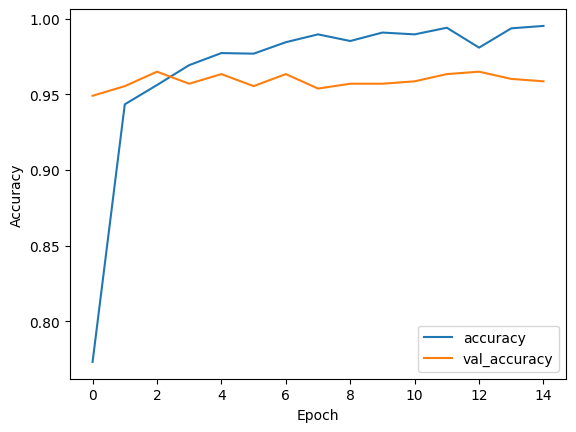

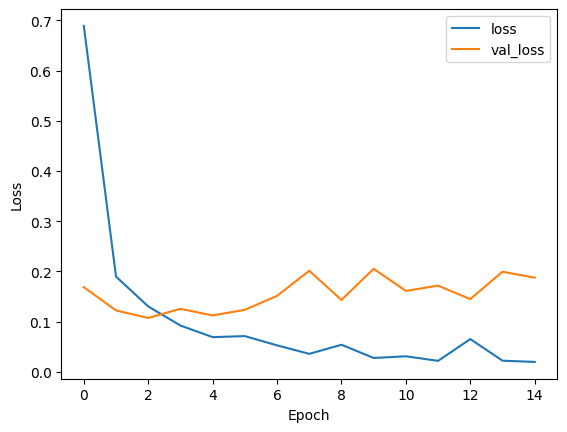

In [23]:
# YOUR CODE GOES HERE
X_train = train_df
y_train = train_enc

test_sequences = tokenizer.texts_to_sequences(test['text_tok'])
X_test = pad_sequences(test_sequences, padding='post', maxlen=MAX_LENGTH)
y_test = test_enc

history = model_2.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate the model
loss, accuracy = model_2.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7145 - loss: 0.6520 - val_accuracy: 0.9140 - val_loss: 0.2985
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9266 - loss: 0.2245 - val_accuracy: 0.9363 - val_loss: 0.1756
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9541 - loss: 0.1365 - val_accuracy: 0.9347 - val_loss: 0.1971
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9621 - loss: 0.1142 - val_accuracy: 0.9427 - val_loss: 0.1894
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9725 - loss: 0.0853 - val_accuracy: 0.9427 - val_loss: 0.1848
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9821 - loss: 0.0622 - val_accuracy: 0.9363 - val_loss: 0.2291
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9797 - loss: 0.0627 - val_accuracy: 0.9427 - val_loss: 0.2197
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9805 - loss: 0.0600 - val_accuracy: 0.9347 - v

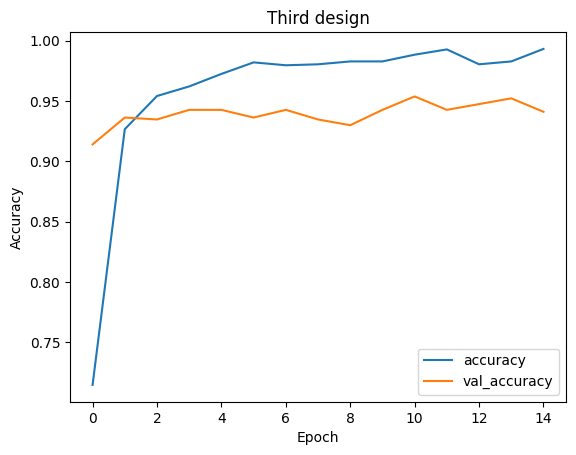

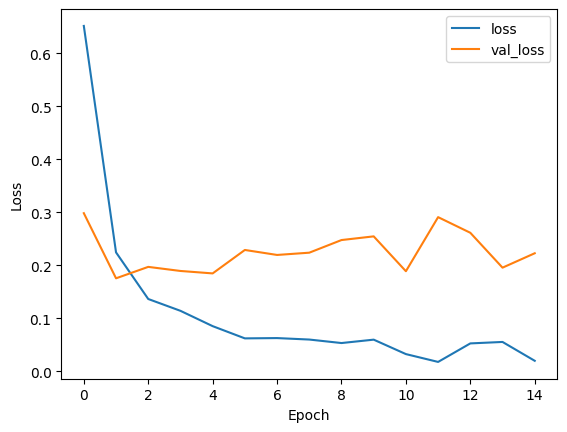

In [24]:
# YOUR CODE GOES HERE
history3 = model3.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate the model
loss3, accuracy3 = model3.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")

import matplotlib.pyplot as plt

plt.plot(history3.history['accuracy'], label='accuracy')
plt.plot(history3.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Third design")
plt.legend()
plt.show()

plt.plot(history3.history['loss'], label='loss')
plt.plot(history3.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Save and Load Model

In [25]:
from tensorflow.keras.models import load_model

# Define a filename for your model
model_filename = 'my_model_2.h5'

# Save the model
model_2.save(model_filename)
print(f"Model saved to {model_filename}")

# To load the model later:
loaded_model = load_model(model_filename)
print(f"Model loaded from {model_filename}")

# You can then use the loaded model for predictions or further evaluation
# For example, to evaluate its performance on the test set:
loss_loaded, accuracy_loaded = loaded_model.evaluate(X_test, y_test)
print(f"\nLoaded Model Test Loss: {loss_loaded:.4f}")
print(f"Loaded Model Test Accuracy: {accuracy_loaded:.4f}")

Model saved to my_model_2.h5
Model loaded from my_model_2.h5
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9586 - loss: 0.1874

Loaded Model Test Loss: 0.1874
Loaded Model Test Accuracy: 0.9586
